## RaNNDy for protein folding 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'          # or 'sans-serif', 'monospace', etc.
plt.rcParams['font.serif'] = ['Computer Modern Serif']  

from matplotlib.colors import ListedColormap
import matplotlib.colors as colors
import time
import jax.random as random

import sys
sys.path.append("/home/s2421480/Documents/PhD_first_year/Extended_summer_project/Codes/d3s/")
import ranndy_jax
import importlib
importlib.reload(ranndy_jax)
from ranndy_jax import RaNNDy, VAMPNets
plt.ion()

import mdtraj as md
#from vampnet import data_generator
#import mdshare
import nglview as nv
import os
import re
from collections import defaultdict

#from contact_map import ContactFrequency, ContactDifference, ContactMap, ContactTrajectory, RollingContactFrequency, ResidueContactConcurrence, plot_concurrence

/home/s2421480/Documents/Github_projects/ranndy/.venv/lib/python3.12/site-packages/nglview/__init__.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Protein-folding data from DE Shaw Research. The data can be acquired from [https://www.deshawresearch.com/]

In [2]:
# Load data  #TODO: Please change the paths here

molecule = 'nug2'  # or 'chignolin'

data_dir = "/home/s2421480/Documents/MD_datasets/"

if molecule == 'nug2':
    molecule_traj_dir = "ProteinG/NuG2-0-protein/"     
else:
    molecule_traj_dir = "Chignolin/CLN025-0-protein/"

# Load .dcd files trajectories
traj_names = []
    
molecule_dir = data_dir + molecule_traj_dir

for filename in sorted(os.listdir(molecule_dir)):
    file_path = os.path.join(molecule_dir, filename)
    traj_names.append(file_path)


In [3]:
# load trajectory with the molecule topology

if molecule == 'nug2':
    path_to_molecule_topology = '/home/s2421480/Documents/MD_datasets/ProteinG/NuG2pdb.pdb'     
else:
    path_to_molecule_topology = '/home/s2421480/Documents/MD_datasets/Chignolin/chignolin_pdb.pdb'
    
traj = md.load(traj_names[::2], top=path_to_molecule_topology) ## for chignolin select whole trajectory

# to take singel copy of chain
if molecule == 'nug2':
    top = traj.topology

    atoms_first56 = [atom.index for atom in top.atoms if atom.residue.index < 56]
    traj = traj.atom_slice(atoms_first56)


In [4]:
traj

<mdtraj.Trajectory with 929251 frames, 435 atoms, 56 residues, and unitcells at 0x712deb113fb0>

In [4]:
# Create the data matrices

traj_X = traj[:-50:50]
traj_Y = traj[50::50]

dis_X = md.compute_contacts(traj_X, contacts='all', scheme='closest-heavy')
dis_Y = md.compute_contacts(traj_Y, contacts='all', scheme='closest-heavy')

data_X = (dis_X[0]).T
data_Y = (dis_Y[0]).T

## Randomized NNs 

In [19]:
operator = 'koopman'
hidden_sizes = [256, 512]  # Hidden layer sizes
final_size = 256  # Output layer size
activation = "tanh"  # activation function
init_weights = 'lecun_normal'
init_bias = 'normal'  # Initialization of weights and biases
init_weights_std = 1.0  # Standard deviation for normal initialization
init_bias_std = 1.0  # Scale for uniform initialization
# direct_link=False  # Whether to use direct link to input # TODO:
random_state = 0  # Random state for reproducibility
n_eigfuncs = 10  # Number of eigenfunctions to compute
kwargs = {} # only needed for Hamiltonian operator


domain_eigf = data_X  # Domain for eigenfunctions

# randomzed neural network for Koopman operator
ranndy = RaNNDy(
    X=data_X,
    operator=operator,
    hidden_sizes=hidden_sizes,
    final_size=final_size,
    activation=activation,
    init_weights_dist=init_weights, 
    init_weights_std=init_weights_std,
    init_bias_dist=init_bias,
    init_bias_std=init_bias_std,
    #direct_link=direct_link,
    random_state=random_state
)

start_time = time.time()  # Start time for RNN eigendecomposition
# eigvals and eigenvectors approximation
Kr, eigvals_rnn, eigvecs_rnn = ranndy.operator_eig_decomp(
    X=data_X,
    Y=data_Y,
    Z=None,
    params=None,
    n=n_eigfuncs,
    epsilon=1e-5,
    kwargs=kwargs)

end_time = time.time()  # End time for RNN eigendecomposition
time_rnn = end_time - start_time
print(f"RNN eigendecomposition time: {time_rnn:.2f} seconds")

eigfuncs_rnn = ranndy.eigenfunctions(
    eigvecs=eigvecs_rnn,
    domain=domain_eigf,
    )

RNN eigendecomposition time: 0.79 seconds


## VAMPNets

In [10]:
# VAMPNet for Koopman operator
vampnet = VAMPNets(X=data_X,
                   hidden_sizes=[256, 512, 256],
                   final_size=5,
                   activation='tanh',
                   init_weights_dist=init_weights, 
                init_weights_std=init_weights_std,
                init_bias_dist=init_bias,
                init_bias_std=init_bias_std,
                   batch_norm=False,
                   random_state=random_state, vampnet=True)

## Operator eigendecomposition using VAMPNet

epochs = 100  # Number of epochs for training
lr = 1e-5  # Learning rate for the optimizer
optim = 'adam'  # Optimizer for training VAMPNet
key= random.PRNGKey(random_state)  


start_time = time.time()  # Start time for VAMPNet eigendecomposition
# eigvals and eigenvectors approximation
params, loss = vampnet.training(X=data_X, Y=data_Y, epochs=epochs, optim=optim, lr=lr, epsilon=1e-5)

end_time = time.time()  # End time for VAMPNet eigendecomposition
time_vampnet = end_time - start_time
print(f"VAMPNet eigendecomposition time: {time_vampnet:.2f} seconds")


Epoch 0, Loss: -3.6499
Epoch 10, Loss: -4.0213
Epoch 20, Loss: -4.2082
Epoch 30, Loss: -4.3272
Epoch 40, Loss: -4.4110
Epoch 50, Loss: -4.4769
Epoch 60, Loss: -4.5352
Epoch 70, Loss: -4.5904
Epoch 80, Loss: -4.6412
Epoch 90, Loss: -4.6831
VAMPNet eigendecomposition time: 129.84 seconds


In [12]:
## eigenfunctions using VAMPNet

Kv, eigvals_vampnet, eigvecs_vampnet = vampnet.koopman_approximation(params=params,
    X=data_X,
    Y=data_Y, n=n_eigfuncs)

eigfuncs_vampnet = vampnet.eigenfunctions(params=params,
    eigvecs=eigvecs_vampnet.T,
    domain=domain_eigf,
    )

## Apply kernel methods like kEDMD and see the pattern in eigenvalues

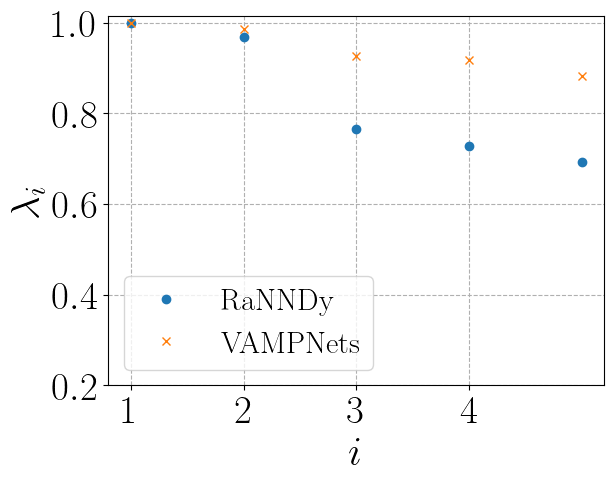

In [20]:
xx = np.arange(1, 6, step=1)
plt.figure()
plt.plot(xx, eigvals_rnn[:5], 'o', label='RaNNDy')
plt.plot(xx, eigvals_vampnet[:5], 'x', label='VAMPNets')
plt.grid(which="minor", linestyle=":")
plt.grid(which="major", linestyle="--")
plt.xlabel(r"$i$", fontsize=30)
plt.ylabel(r"$\lambda_i$", fontsize=30)
plt.legend(fontsize=22, loc='best')
plt.xticks(np.arange(1, 5, 1), fontsize=28)
plt.yticks(np.arange(0.2, 1.1, 0.2), fontsize=28)
#plt.savefig('/home/s2421480/Documents/PhD_third_year/rnn_closed_notebooks/figures/nug2_eigvals.pdf', bbox_inches='tight', dpi=300)
plt.show()

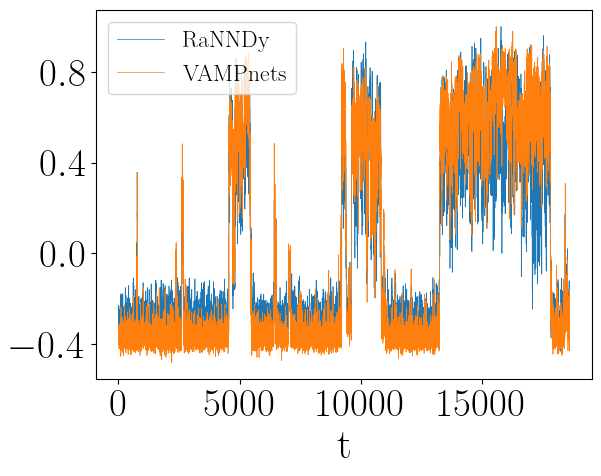

In [ ]:
# eigenfunctions plot

k = 1
r_rnn = eigfuncs_rnn[k, :]
r_vampnet = eigfuncs_vampnet[k, :]
eigf2_rnn = np.real(-r_rnn/np.amax(np.abs(r_rnn))).reshape(data_X.shape[1], 1)
eigf2_vampnet = np.real(r_vampnet/np.amax(np.abs(r_vampnet))).reshape(data_X.shape[1], 1)

plt.figure()
plt.plot(eigf2_rnn, linewidth=0.5, label = 'RaNNDy')
plt.plot(eigf2_vampnet, linewidth=0.5, label = 'VAMPnets')
plt.legend(fontsize=17, loc='upper left')
plt.xlabel('t', fontsize=30)
#plt.ylabel('Eigenfunction', fontsize=37)
plt.xticks(np.arange(0, 20000, 5000), fontsize=28)
plt.yticks(np.arange(-0.4, 1.1, 0.4), fontsize=28)
#plt.savefig('../figures/nug2_eigfuncs.pdf', bbox_inches='tight', dpi=300)
plt.show()

## Extracting the states

In [37]:
## Divide the states based on a cutoff

cutoff_rnn = 0.0
cutoff_vampnet = 0.1

states_1_rnn = list(i for i, x in enumerate(eigf2_rnn) if x > cutoff_rnn)
states_2_rnn = list(i for i, x in enumerate(eigf2_rnn) if x < cutoff_rnn)
states_1_vampnet = list(i for i, x in enumerate(eigf2_vampnet) if x > cutoff_vampnet)
states_2_vampnet = list(i for i, x in enumerate(eigf2_vampnet) if x < cutoff_vampnet)

In [38]:
# Getting the frmaes from trajectory for each state for RNN

state_1_frames_rnn = traj_X[states_1_rnn]
state_2_frames_rnn = traj_X[states_2_rnn]


# Getting the frmaes from trajectory for each state for VAMPNets

state_1_frames_vampnet = traj_X[states_1_vampnet]
state_2_frames_vampnet = traj_X[states_2_vampnet]

In [39]:
print('Number of frames in state 1 using RNN: ', len(states_1_rnn))
print('Number of frames in state 2 using RNN: ', len(states_2_rnn))
print('Number of frames in state 1 using VAMPNets: ', len(states_1_vampnet))
print('Number of frames in state 2 using VAMPNets: ', len(states_2_vampnet))

Number of frames in state 1 using RNN:  6879
Number of frames in state 2 using RNN:  11706
Number of frames in state 1 using VAMPNets:  6857
Number of frames in state 2 using VAMPNets:  11728


## Calculate the accracy to report as number of misclassified frames/total frames. Optimize RNN more before reporting final accuracies.

In [ ]:
# # # saving the frames for vampnet

# state_1_frames_vampnet.save_pdb('/home/s2421480/Documents/MD_datasets/ProteinG/state_1_vampnet')
# state_2_frames_vampnet.save_pdb('/home/s2421480/Documents/MD_datasets/ProteinG/state_2_vampnet')

# # # saving the frames for rnn

# state_1_frames_rnn.save_pdb('/home/s2421480/Documents/MD_datasets/ProteinG/state_1_rnn')
# state_2_frames_rnn.save_pdb('/home/s2421480/Documents/MD_datasets/ProteinG/state_2_rnn')

## Contact map of the trajectories

In [25]:
import contact_map
from contact_map import ContactFrequency, ContactTrajectory

In [26]:
folded_contact_freq = ContactFrequency(state_1_frames_rnn)
unfolded_contact_freq = ContactFrequency(state_2_frames_rnn)
#part_folded_contact_freq = ContactFrequency(part_folded_frames, cutoff=0.5)

/tmp/ipykernel_12699/729882397.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  seismic = cm.get_cmap('seismic', 256)


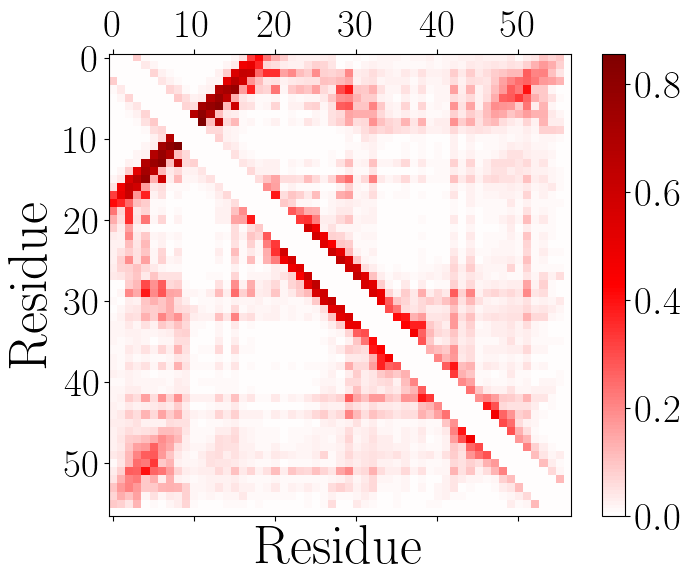

In [ ]:
contact_df = unfolded_contact_freq.residue_contacts.df

# Slice first 61 residues
subset_df = contact_df.loc[0:56, 0:56]

# Replace NaNs with 0
subset_df_clean = subset_df.fillna(0)

# Prepare the plot
fig, ax = plt.subplots(figsize=(8, 6))

seismic = cm.get_cmap('seismic', 256)
white_to_red = ListedColormap(seismic(np.linspace(0.5, 1, 256)))

# Plot using matshow
cax = ax.matshow(subset_df_clean.values, cmap=white_to_red)

# Customize axes
plt.xlabel("Residue", fontsize=39)
plt.ylabel("Residue", fontsize=39)
plt.xticks(range(0, 57, 10), fontsize=28)
plt.yticks(range(0, 57, 10), fontsize=28)

# Add colorbar
cbar = fig.colorbar(cax)
cbar.ax.tick_params(labelsize=28)
#plt.savefig('/home/s2421480/Documents/PhD_third_year/rnn_closed_notebooks/figures/nug2_unfolded_contact.pdf', bbox_inches='tight', dpi=300)
plt.show()

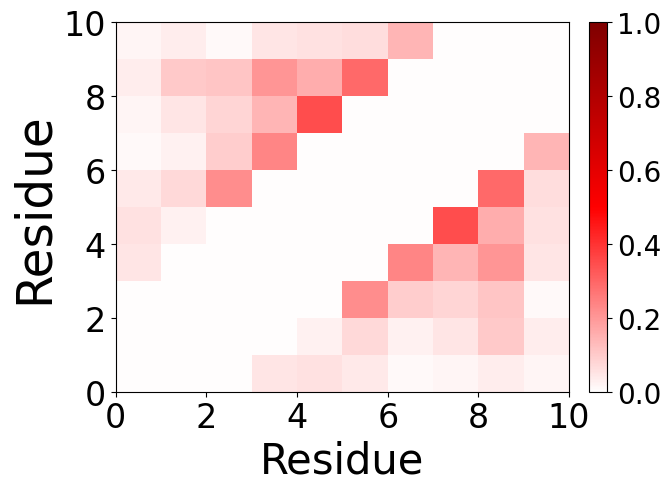

In [55]:
#%%time

fig, ax = folded_contact_freq.residue_contacts.plot()
#fig, ax = part_folded_contact_freq.residue_contacts.plot()
#fig, ax = unfolded_contact_freq.residue_contacts.plot()

plt.xlabel("Residue", fontsize=30)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
#plt.colorbar(fontsize=24)
fig.axes[1].yaxis.set_tick_params(labelsize=20)
_ = plt.ylabel("Residue", fontsize=35)
#plt.savefig('/home/s2421480/Documents/PhD_third_year/rnn_closed_notebooks/figures/chig_folded_contact.pdf', bbox_inches='tight', dpi=300)

## Ensemble learning

In [6]:
n_models = 100  # Number of models to ensemble
(avg_eigvals, avg_eigfuncs, eigvals_plus, eigvals_minus, eigfuncs_plus, eigfuncs_minus) = ranndy.ensemble_models(n_models=n_models, X=data_X, Y=data_Y, Z=None, n=n_eigfuncs, epsilon=1e-5, kwargs=kwargs)

/home/s2421480/Documents/PhD_third_year/rnn_closed_notebooks/experiments/algorithms_jax.py:652: ComplexWarning: Casting complex values to real discards the imaginary part
  ensem_eigvals[:, i] = eigvals
/home/s2421480/Documents/PhD_third_year/rnn_closed_notebooks/experiments/algorithms_jax.py:654: ComplexWarning: Casting complex values to real discards the imaginary part
  ensem_eigfuncs[:, :, i] = eigfuncs


/tmp/ipykernel_6673/3899234087.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)


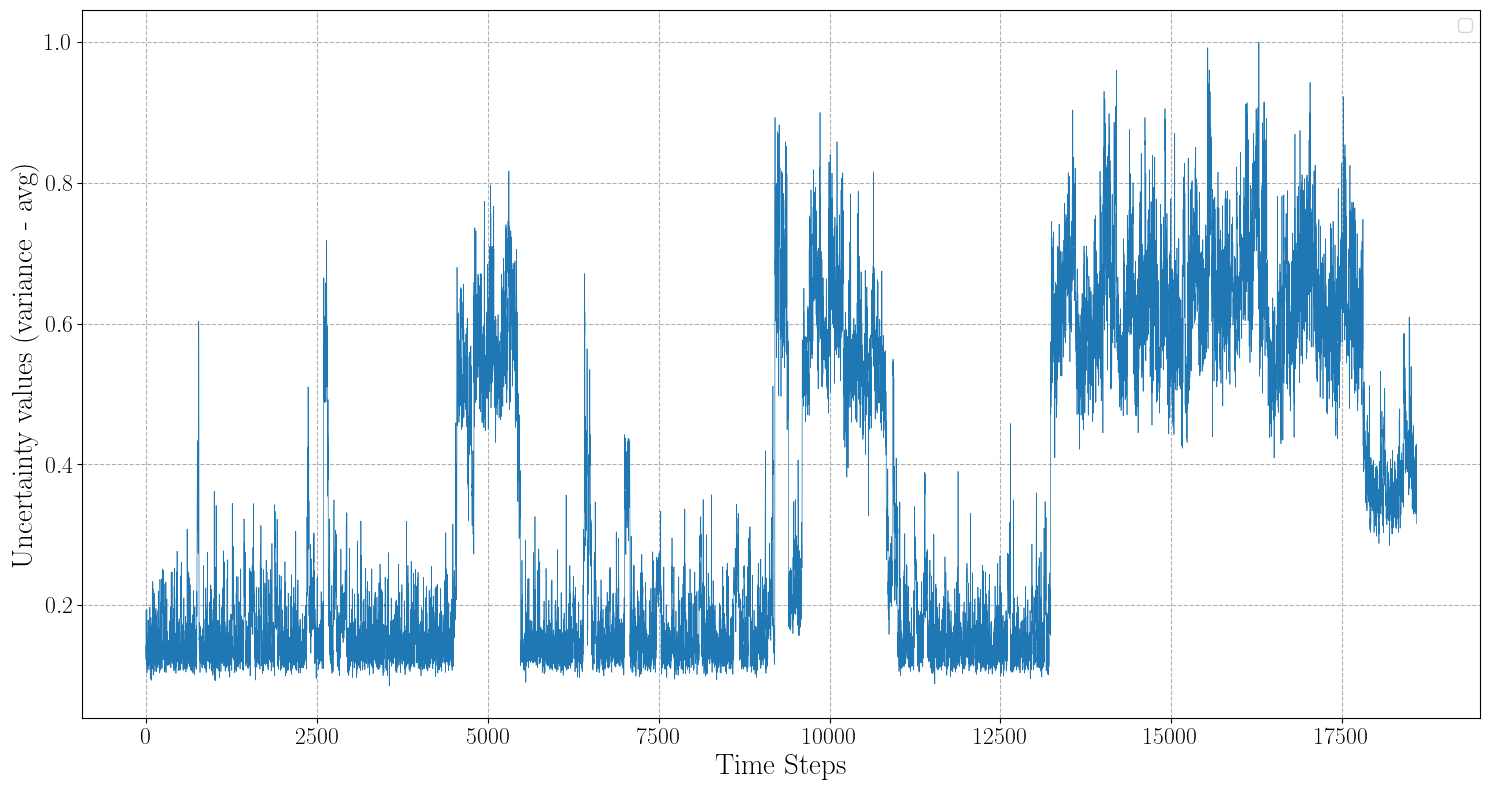

In [8]:
# Plotting the average eigenfunction with uncertainty

i = 1  # Index of the eigenfunction to plot
fig, ax = plt.subplots(figsize=(15, 8))

avg = np.real(avg_eigfuncs[i, :])
plus = np.real(eigfuncs_plus[i, :])
minus = np.real(eigfuncs_minus[i, :])
norm = np.amax(np.abs(avg))
avg /= norm

local_uncertainty = np.abs(plus - minus) / 2
local_uncertainty /= np.max(local_uncertainty)

xx = np.arange(data_X.shape[1])  # or use time = data_X[0, :] if those are actual time points

### Plot the average eigenfunction

ax.plot(xx, local_uncertainty, linewidth=0.5)
# ax.plot(xx, avg, color='black', linewidth=0.5, label=fr"$\varphi_{i+1}$")
# ax.plot(xx, avg + local_uncertainty, color='red', linewidth=0.5, label='Upper Bound')
# ax.plot(xx, avg - local_uncertainty, color='blue', linewidth=0.5, label='Lower Bound')

# ax.fill_between(xx, avg - local_uncertainty, avg + local_uncertainty,
#                 color='green', alpha=0.3, label='Uncertainty')

# Labels and appearance
ax.set_xlabel('Time Steps', fontsize=21)
ax.set_ylabel('Uncertainty values (variance - avg)', fontsize=21)
ax.grid(which='major', linestyle='--')
ax.grid(which='minor', linestyle=':')
#ax.set_title("Eigenfunction with Local Uncertainty", fontsize=18)
ax.legend(fontsize=12)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.tight_layout()
#plt.savefig('nug2_eigfunc_uncertainty.png')
plt.show()
